In [1]:
import sys
!{sys.executable} -m pip install interpax
!pip install git+https://gitlab.in2p3.fr/lisa-apc/jexplore.git


  Cloning https://gitlab.in2p3.fr/lisa-apc/jexplore.git to /tmp/pip-req-build-cl4iazth
  Running command git clone --filter=blob:none --quiet https://gitlab.in2p3.fr/lisa-apc/jexplore.git /tmp/pip-req-build-cl4iazth
  Resolved https://gitlab.in2p3.fr/lisa-apc/jexplore.git to commit 368836e3dddd20cb431589fdfb8c6ac6ccb308aa
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import corner
import json
import os
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
os.environ["XLA_PYTHON_CLIENT_ALLOCATOR"] = "platform"
import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp
from jax import jit
from jax import vmap
from jax.scipy.stats import norm
import gc
import discovery as ds
import deterministic_eccentric as det_ecc

import jexplore.tools.distributions as d
from jexplore.backends import DefaultBackend
from jexplore.sampler import JaxSampler, Steps
from jexplore.sampling import EpochMH, SamplingMH
from jexplore.steps import Stretch, TSwap, DEStep


In [3]:
with open('injected_params.json', 'r') as f:
    injected_dict = json.load(f)

with open('prior_dict.json', 'r') as f:
    priors_all = json.load(f)


In [4]:
feathers_path = 'EPTA_feather_DR2new/'

s_dsfiles = np.sort(os.listdir(feathers_path))
# use only first 6 pulsars for the tutorial
s_dsfiles = s_dsfiles[:6]

d_psrs = [ds.pulsar.Pulsar.read_feather(feathers_path + f'{psrfile}') for psrfile in s_dsfiles]
timedelay = det_ecc.make_delay_eccentric()
cw_common = ['cw_cos_gwtheta', 'cw_gwphi', 'cw_log10_M', 'cw_nu',
             'cw_log10_dist', 'cw_log10_Forb', 'cw_cos_inc', 'cw_psi', 'cw_gamma0',
             'cw_xi0','cw_e0']

def injection_EPTA_DR2new(psrs, crn_components = 30):

    pslmodels = []
    tspan = ds.getspan(psrs)
    for p in psrs:
        tspan = ds.getspan(p)

        model = [p.residuals, ds.makenoise_measurement(p, p.noisedict, tnequad = True), ds.makegp_timing(p, svd=True, variance =1e-40), ds.makedelay(p, timedelay, common=cw_common, name='cw')]
        
        model.append(ds.makegp_fourier(p, ds.powerlaw, crn_components, T=tspan, name='crn', common=['crn_log10_A', 'crn_gamma']))
        pslmodels.append(ds.PulsarLikelihood(model))

    tspan = ds.getspan(psrs)
    t0 = ds.getstart(psrs)
    return ds.GlobalLikelihood(psls = pslmodels)

injection = injection_EPTA_DR2new(d_psrs)
print(injection.logL.params)

key = jax.random.PRNGKey(290699)
key, injected_res = injection.sample(key, injected_dict)

['J0030+0451_cw_psrdist', 'J0030+0451_cw_xi0p', 'J0613-0200_cw_psrdist', 'J0613-0200_cw_xi0p', 'J0751+1807_cw_psrdist', 'J0751+1807_cw_xi0p', 'J0900-3144_cw_psrdist', 'J0900-3144_cw_xi0p', 'J1012+5307_cw_psrdist', 'J1012+5307_cw_xi0p', 'J1022+1001_cw_psrdist', 'J1022+1001_cw_xi0p', 'crn_gamma', 'crn_log10_A', 'cw_cos_gwtheta', 'cw_cos_inc', 'cw_e0', 'cw_gamma0', 'cw_gwphi', 'cw_log10_Forb', 'cw_log10_M', 'cw_log10_dist', 'cw_nu', 'cw_psi', 'cw_xi0']


In [5]:
del feathers_path, s_dsfiles, timedelay, cw_common
gc.collect()

#  save in the psrs residuals
for ii, psr in enumerate(d_psrs):
    psr.residuals = np.array(injected_res[ii]).squeeze()

del injected_res
gc.collect()


0

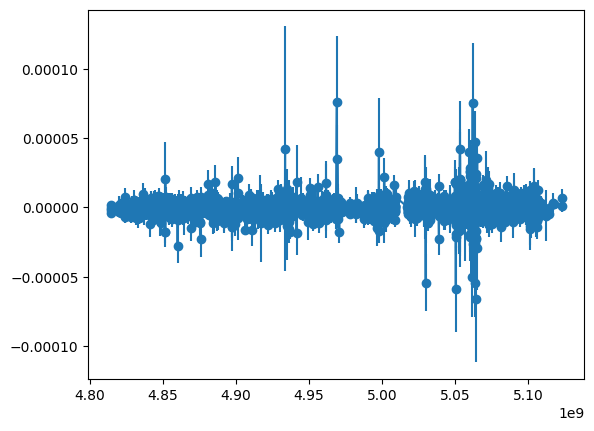

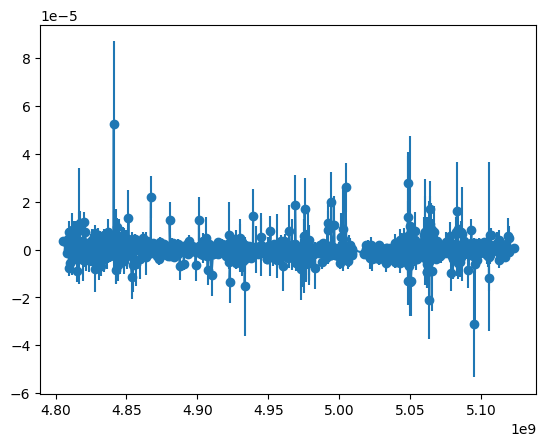

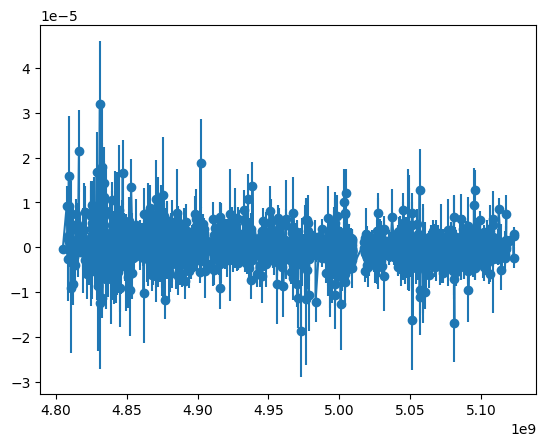

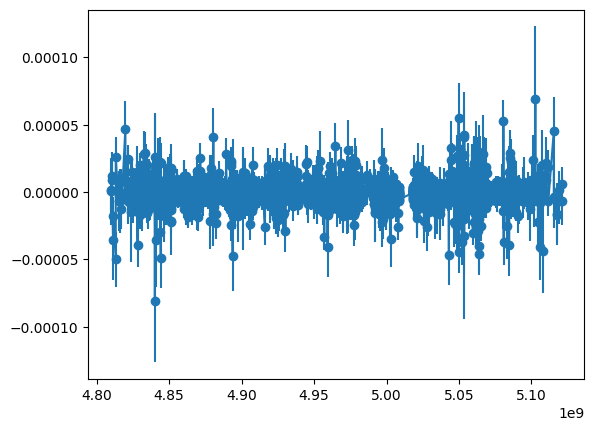

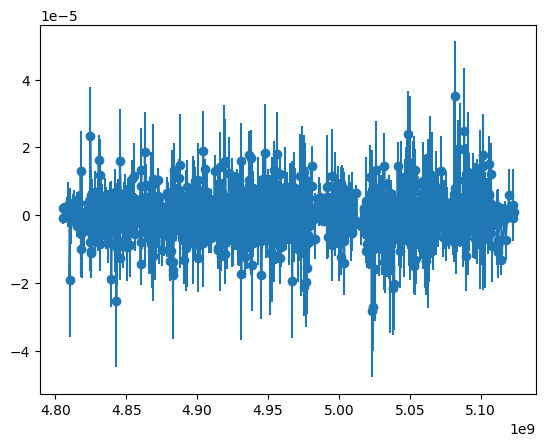

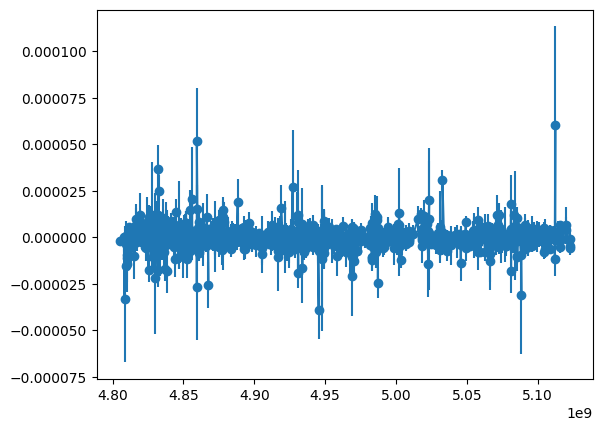

In [6]:
for i in range(len(d_psrs)):
    plt.errorbar(d_psrs[i].toas, d_psrs[i].residuals, d_psrs[i].toaerrs, marker ='o')
    
    plt.show()


def fit_EPTA_DR2new(psrs, crn_components = 30):

    pslmodels = []
    tspan = ds.getspan(psrs)
    for p in psrs:
        tspan = ds.getspan(p)
        model = [p.residuals, ds.makenoise_measurement(p, p.noisedict, tnequad = True), ds.makegp_timing(p, svd=True)]

        model.append(ds.makegp_fourier(p, ds.powerlaw, crn_components, T=tspan, name='crn', common=['crn_log10_A', 'crn_gamma']))
        pslmodels.append(ds.PulsarLikelihood(model))

    tspan = ds.getspan(psrs)
    t0 = ds.getstart(psrs)
    return ds.GlobalLikelihood(psls = pslmodels)


crn_dict = {
    'crn_gamma': injected_dict['crn_gamma'],
    'crn_log10_A': injected_dict['crn_log10_A']
}

gl = fit_EPTA_DR2new(d_psrs)
params_to_sample = gl.logL.params
jlogl = jax.jit(gl.logL)

# Warm up (Compiles)
_ = jlogl(crn_dict)

In [7]:
n_params = len(params_to_sample)

# Separate normal and uniform parameters
normal_indices = []
uniform_indices = []
normal_mus = []
normal_sigmas = []
uniform_lbs = []
uniform_ubs = []

for i, name in enumerate(params_to_sample):
    prior = priors_all[name]
    if prior['dist'] == 'normal':
        normal_indices.append(i)
        normal_mus.append(prior['mu'])
        normal_sigmas.append(prior['sigma'])
    else:  # uniform
        uniform_indices.append(i)
        uniform_lbs.append(prior['min'])
        uniform_ubs.append(prior['max'])

print(f"Normal indices: {normal_indices}")
print(f"Uniform indices: {uniform_indices}")
print(f"Total params: {n_params}")
print(f"Normal + Uniform = {len(normal_indices) + len(uniform_indices)}")

normal_mus = jnp.array(normal_mus)
normal_sigmas = jnp.array(normal_sigmas)
uniform_lbs = jnp.array(uniform_lbs)
uniform_ubs = jnp.array(uniform_ubs)
eps = 1e-10

normal_indices = jnp.array(normal_indices)
uniform_indices = jnp.array(uniform_indices)



@jax.jit
def prior_transform_single(u):
    """Transform [0,1]^n -> physical parameters"""
    x = jnp.zeros(n_params)

    # Transform normal parameters (extract subset, transform, assign back)
    if len(normal_indices) > 0:
        u_normal = u[normal_indices]  # Shape: (n_normal,)
        x_normal = normal_mus + jnp.maximum(normal_sigmas, eps) * ndtri(u_normal)
        x = x.at[normal_indices].set(x_normal)

    # Transform uniform parameters (extract subset, transform, assign back)
    if len(uniform_indices) > 0:
        u_uniform = u[uniform_indices]  # Shape: (n_uniform,)
        x_uniform = uniform_lbs + u_uniform * (uniform_ubs - uniform_lbs)
        x = x.at[uniform_indices].set(x_uniform)

    return x



@jax.jit
def physical_to_unit(x):
    """Transform physical parameters -> [0,1]^n hypercube"""
    u = jnp.zeros(n_params)
    if len(normal_indices) > 0:
        x_normal = x[normal_indices]
        u_normal = ndtr((x_normal - normal_mus) / jnp.maximum(normal_sigmas, eps))
        u = u.at[normal_indices].set(u_normal)
    if len(uniform_indices) > 0:
        x_uniform = x[uniform_indices]
        u_uniform = (x_uniform - uniform_lbs) / (uniform_ubs - uniform_lbs)
        u = u.at[uniform_indices].set(u_uniform)
    return u

@jax.jit
def loglike_single(u):
    x = prior_transform_single(u)
    x_dict = dict(zip(params_to_sample, x))
    logL = jlogl(x_dict)
    logL = jnp.where(jnp.isfinite(logL), logL, -1e30)
    return logL


Normal indices: []
Uniform indices: [0, 1]
Total params: 2
Normal + Uniform = 2


In [8]:
ndim = n_params
nwalker = 20
temps = jnp.linspace(1, 3, 2)
ntemps = len(temps)

sampling = SamplingMH(dim=ndim, nwalker=nwalker, temps=temps, loglik= loglike_single, logprior=d.Uniform(dim=ndim, minval = 0, maxval =1).leval)
steps = Steps([{TSwap(permute = True).builder: 1.0}, {Stretch(permute = True).builder: 0.3}, {DEStep(permute = True).builder: 0.7}])
DefaultBackend = DefaultBackend(burn=0, outdir = 'chains')


In [9]:
key, subkey = jax.random.split(key)
initial_points = jax.random.uniform(subkey, shape=(ntemps * nwalker, ndim), minval=1e-6, maxval=1-1e-6)
print(initial_points.shape)  # (ntemps*nwalker, ndim)

iepoch = EpochMH({"p": initial_points})

sampler = JaxSampler(sampling, steps, DefaultBackend)

fepoch = sampler.run(iepoch, niters=500, nepoch=1, seed=13)


(40, 2)


In [10]:
import read_chains
import importlib

importlib.reload(read_chains)
chains_GWB, loglike_GWB, params_GWB, injected_GWB, cov_matrix_GWB, k_GWB = read_chains.load_ptmcmc_chains('chains', ntemps=2, burn_in=int(10), thin=5)

Found 1 chain file(s): ['epochs_1.h5']
nwalkers=20, ntemps=2, nparams=2, niters=500
chains_physical shape: (98, 2, 20, 2)
loglike shape:         (98, 2, 20)


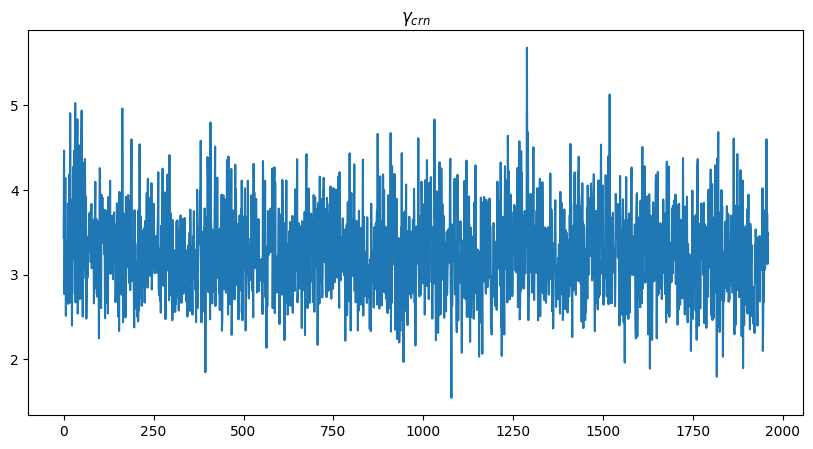

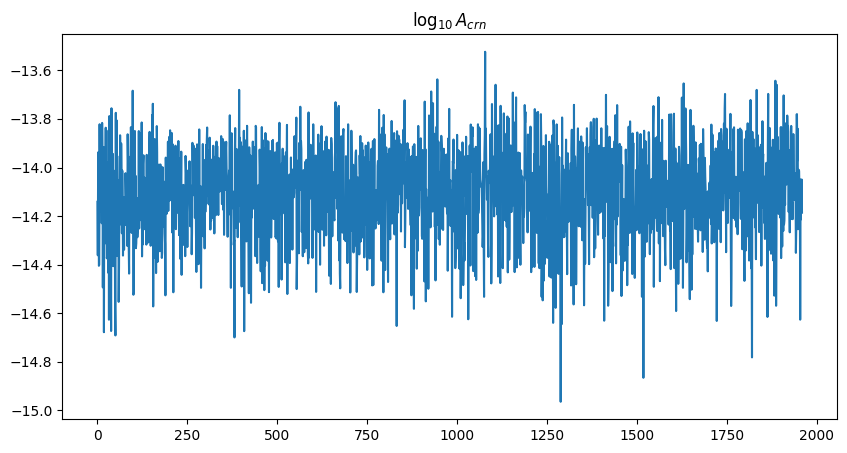

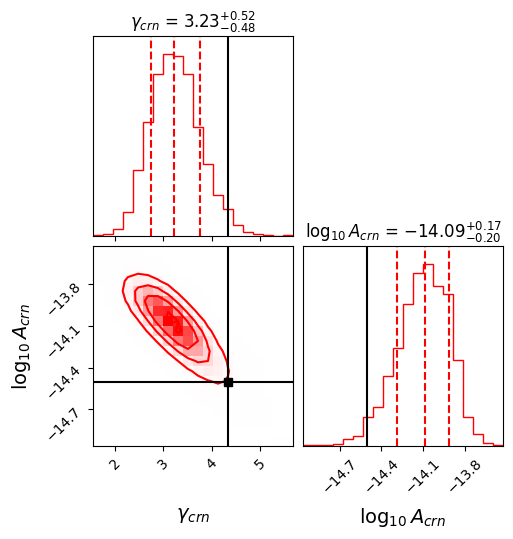

In [11]:
# Nomi dei parametri (usa LaTeX per un look professionale)

cold_chain_GWB = chains_GWB[:, 0, :, :]       # cold temperature 

labels_crn = [r'$\gamma_{crn}$', r'$\log_{10} A_{crn}$']

for param in range(len(params_GWB)):
    plt.figure(figsize = (10,5))
    plt.plot(cold_chain_GWB[:,:,param].flatten())
    plt.title(labels_crn[param])
    plt.show()
    
# 2. Configurazione del plot
fig = corner.corner(
    cold_chain_GWB.reshape(-1, cold_chain_GWB.shape[-1]), 
    labels=labels_crn,
    truths=list(crn_dict.values()),          # Linee di riferimento (es. valori veri)
    truth_color="k",            # Colore delle linee di riferimento
    quantiles=[0.16, 0.5, 0.84],      # Mostra mediana e 1-sigma
    show_titles=True,                 # Mostra i valori sopra gli istogrammi
    title_kwargs={"fontsize": 12},
    label_kwargs = {"fontsize": 14},
    color='red',                  # Colore dei dati
    smooth=1.0,                       # Applica un leggero smoothing
    plot_datapoints=False,            # Rimuove i singoli punti per pulizia
    fill_contours=False,               # Colora l'interno dei contorni
)

# 3. Personalizzazione extra
#plt.suptitle("Discovery Results: WN+CRN Analysis", fontsize=16)
plt.show()